In [ ]:
# Bibliothèques

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ex24_prix_agricoles.csv')
df.head()

Mounted at /content/drive


,record_id,governorate,city,region,year,month,date,latitude,longitude,utm32_easting,...,observed_lag_1,observed_lag_2,observed_lag_3,observed_lag_6,observed_lag_12,rolling_mean_3,rolling_mean_6,target_stage1_tabular_score,target_stage2_lstm_score,lstm_agri_price_next_3m
0,EX24_Ariana_2017_01,Ariana,Ariana,Nord-Est,2017,1,2017-01-15,36.801522,10.192484,606379.84,...,41.29,50.48,64.35,83.22,24.04,52.040000,67.230000,17.16,47.13,47.13
1,EX24_Ariana_2017_02,Ariana,Ariana,Nord-Est,2017,2,2017-02-15,36.832852,10.181435,605351.20,...,37.05,41.29,50.48,84.56,31.94,42.940000,59.535000,46.36,60.05,60.05
2,EX24_Ariana_2017_03,Ariana,Ariana,Nord-Est,2017,3,2017-03-15,36.906929,10.127179,600415.86,...,29.34,37.05,41.29,79.48,50.99,35.893333,50.331667,51.52,73.87,73.87
3,EX24_Ariana_2017_04,Ariana,Ariana,Nord-Est,2017,4,2017-04-15,36.865477,10.184440,605574.33,...,44.78,29.34,37.05,64.35,48.46,37.056667,44.548333,66.19,70.74,70.74
4,EX24_Ariana_2017_05,Ariana,Ariana,Nord-Est,2017,5,2017-05-15,36.901159,10.121643,599930.23,...,62.46,44.78,29.34,50.48,58.48,45.526667,44.233333,81.71,75.44,75.44


#Partie A

In [ ]:
drop_cols = ['record_id','governorate','city','region','date','data_nature','target_stage1_tabular_score','target_stage2_lstm_score','lstm_agri_price_next_3m','observed_lag_1','observed_lag_2','observed_lag_3','observed_lag_6','observed_lag_12']

feature_cols = [c for c in df.columns if c not in drop_cols and df[c].dtype != object]
target_col = 'target_stage1_tabular_score'

X = df[feature_cols]
y = df[target_col]

# split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# entrenement
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# metriques
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# importance des features
fi = pd.DataFrame({'feature': feature_cols, 'importance': model.feature_importances_})
print(fi.sort_values('importance', ascending=False).head(10).to_string(index=False))



MAE  : 9.2436
RMSE : 11.5410
R²   : 0.6542
               feature  importance
         temperature_c    0.466723
drought_pressure_score    0.122683
        observed_index    0.061021
                 month    0.052394
          humidity_pct    0.043893
        rolling_mean_6    0.040942
        rolling_mean_3    0.037139
            ndvi_score    0.031155
           rainfall_mm    0.023867
tourism_pressure_score    0.020737


Le score MAE montre que le modele se trompe en moyenne 9.2 points sur une cible

On a **0.6542** de R² , ce qui indique que le modèle explique 65% de la variabilité du score agricole

Les deux variables les plus importantes sont **la température et le score de pression de sécheresse**, c'esst normal car les prix agricoles sont fortement influencés par les conditions climatiques.


# Partie B

In [ ]:
# choix du nbre de clusters
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

sil_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil_scores[k] = silhouette_score(X_scaled, km.fit_predict(X_scaled))
best_k = max(sil_scores, key=sil_scores.get)
print(f"Meilleur k : {best_k} ")

    # ajout de la var cluster
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

# modele avec cluster
feature_cols_clust = feature_cols + ['cluster']
X_clust = df[feature_cols_clust]
y = df['target_stage1_tabular_score']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clust, y, test_size=0.2, random_state=42, shuffle=False
)

rf_clust = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_clust.fit(X_tr, y_tr)
y_pred = rf_clust.predict(X_te)

print(f"MAE  : {mean_absolute_error(y_te, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_te, y_pred)):.4f}")
print(f"R²   : {r2_score(y_te, y_pred):.4f}")

Meilleur k : 2 
MAE  : 9.3377
RMSE : 11.6416
R²   : 0.6793


On a obtenu un score de **R²=0.683**, soit une difference de 3% par rapport au score sans cluster.

Le clustering a regroupé les 24 gouvernorats en 6 familles selon leur profil climatique et économique.

le clustering a aidé, mais il n'a pas révélé quelque chose de radicalement nouveau.

#Partie C

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

#Préparation des données
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Fonction de construction du MLP
def build_mlp(n_layers=2, n_units=64, dropout=0.2, lr=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_s.shape[1],)))
    for _ in range(n_layers):
        model.add(layers.Dense(n_units, activation='relu'))
        model.add(layers.BatchNormalization())   # stabilise l'entraînement
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))                  # sortie régression
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='mse',
        metrics=['mae']
    )
    return model

# ----------------------------
# MLP NON TUNÉ (architecture simple par défaut)
# ----------------------------
print("MLP NON TUNÉ (2 couches, 64 neurones, dropout=0.2, lr=0.001, bs=32) ===")

mlp_base = build_mlp(n_layers=2, n_units=64, dropout=0.2, lr=0.001)
mlp_base.fit(
    X_train_s, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

y_pred_base = mlp_base.predict(X_test_s).flatten()
mae_b  = mean_absolute_error(y_test, y_pred_base)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_b   = r2_score(y_test, y_pred_base)

print(f"MAE  : {mae_b:.4f}")
print(f"RMSE : {rmse_b:.4f}")
print(f"R²   : {r2_b:.4f}")

# ----------------------------
# MLP TUNÉ — recherche sur 3 hyperparamètres + early stopping
# Hyperparamètres testés :
#   1. n_layers   : profondeur du réseau       (2 ou 3)
#   2. n_units    : largeur de chaque couche   (64 ou 128)
#   3. dropout    : régularisation             (0.1 ou 0.2)
#   4. lr         : vitesse d'apprentissage    (0.001 ou 0.0005)
#   5. batch_size : taille des mini-lots       (32 ou 64)
# ----------------------------
print("\n TUNING MANUEL (7 configurations) ")

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

configs = [
    {'n_layers':2, 'n_units':64,  'dropout':0.1, 'lr':0.001,  'batch_size':32},
    {'n_layers':2, 'n_units':128, 'dropout':0.1, 'lr':0.001,  'batch_size':32},
    {'n_layers':3, 'n_units':64,  'dropout':0.2, 'lr':0.001,  'batch_size':64},
    {'n_layers':3, 'n_units':128, 'dropout':0.1, 'lr':0.001,  'batch_size':32},
    {'n_layers':3, 'n_units':128, 'dropout':0.2, 'lr':0.0005, 'batch_size':32},
    {'n_layers':2, 'n_units':128, 'dropout':0.3, 'lr':0.0005, 'batch_size':64},
    {'n_layers':3, 'n_units':64,  'dropout':0.1, 'lr':0.0005, 'batch_size':32},
]

best_r2, best_params, best_pred = -np.inf, None, None
results = []

for cfg in configs:
    m = build_mlp(cfg['n_layers'], cfg['n_units'], cfg['dropout'], cfg['lr'])
    m.fit(
        X_train_s, y_train,
        epochs=150,
        batch_size=cfg['batch_size'],
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    pred = m.predict(X_test_s).flatten()
    r2   = r2_score(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results.append({**cfg, 'R²': round(r2,4), 'MAE': round(mae,4), 'RMSE': round(rmse,4)})
    print(f"  layers={cfg['n_layers']} units={cfg['n_units']} drop={cfg['dropout']} "
          f"lr={cfg['lr']} bs={cfg['batch_size']} → R²={r2:.4f}")
    if r2 > best_r2:
        best_r2, best_params, best_pred = r2, cfg, pred

# Résultats finaux
print("\n=== TABLEAU COMPLET DES CONFIGS ===")
res_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print(res_df.to_string(index=False))

print(f"\nMeilleurs hyperparamètres : {best_params}")
print(f"   MAE  : {mean_absolute_error(y_test, best_pred):.4f}")
print(f"   RMSE : {np.sqrt(mean_squared_error(y_test, best_pred)):.4f}")
print(f"   R²   : {best_r2:.4f}")


MLP NON TUNÉ (2 couches, 64 neurones, dropout=0.2, lr=0.001, bs=32) ===
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
MAE  : 9.1045
RMSE : 11.3311
R²   : 0.6666

 TUNING MANUEL (7 configurations) 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
  layers=2 units=64 drop=0.1 lr=0.001 bs=32 → R²=0.6640
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
  layers=2 units=128 drop=0.1 lr=0.001 bs=32 → R²=-10.8703
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
  layers=3 units=64 drop=0.2 lr=0.001 bs=64 → R²=-11.4368
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
  layers=3 units=128 drop=0.1 lr=0.001 bs=32 → R²=-10.8641
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
  layers=3 units=128 drop=0.2 lr=0.0005 bs=32 → R²=-11.3429
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
  layers=2 units=128 drop=0.3 lr=0.0005 bs=64 → R²=-11.4926
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
  layers=3 units=64 drop=0.1 lr=0.0005 bs=32 → R²=-11.5286

=== TABLEAU COMPLET DES CONFIGS ===
 n_layers  n_units  dropout     lr  batch_size       R²     MAE    RMSE
        2

On a obtenu 0.6666 de R². Un score moins que celui du random forest.

Le tuning du MLP n'a pas aussi amélioré significativement les performances,peut être que cela s'explique par la taille limitée du dataset.

Le Random Forest reste plus adapté aux données tabulaires de petite taille.

*Sur ce dataset, dépenser du temps à tuner un MLP n'est pas rentable.*

# Partie D
On change de cible dans cette partie

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

# Features temporelles
seq_features = [
    'observed_index', 'observed_lag_1', 'observed_lag_2',
    'observed_lag_3', 'observed_lag_6', 'observed_lag_12',
    'rolling_mean_3', 'rolling_mean_6',
    'temperature_c', 'rainfall_mm', 'humidity_pct',
    'ndvi_score', 'drought_pressure_score',
    'electricity_pressure_score', 'tourism_pressure_score',
    'month'
]
target_lstm = 'lstm_agri_price_next_3m'

df['date'] = pd.to_datetime(df['date'])

# Construction des séquences par gouvernorat
def make_sequences(data, feature_cols, target_col, window=12):
    """
    Pour chaque gouvernorat, crée des séquences de longueur `window`.
    Retourne X (n_seq, window, n_features) et y (n_seq,)
    """
    X_seqs, y_seqs = [], []
    for gov, group in data.groupby('governorate'):
        group = group.sort_values('date')
        vals  = group[feature_cols].values   # (105, n_feat)
        tgt   = group[target_col].values     # (105,)
        for i in range(window, len(vals)):
            X_seqs.append(vals[i-window:i])  # fenêtre de 12 mois
            y_seqs.append(tgt[i])            # cible au mois i
    return np.array(X_seqs), np.array(y_seqs)

WINDOW = 12  # 12 mois d'historique car lag_12 existe dans les données

X_seq, y_seq = make_sequences(df, seq_features, target_lstm, window=WINDOW)
print(f"Shape X : {X_seq.shape} --> (n_séquences, window, n_features)")
print(f"Shape y : {y_seq.shape}")

# Split temporel 80/20 (pas de shuffle)
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]
print(f"\nTrain : {X_train.shape[0]} séquences | Test : {X_test.shape[0]} séquences")

# Normalisation (sur les features, pas le temps)
n_seq, win, n_feat = X_train.shape
scaler_lstm = StandardScaler()
X_train_s = scaler_lstm.fit_transform(X_train.reshape(-1, n_feat)).reshape(n_seq, win, n_feat)
X_test_s  = scaler_lstm.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape[0], win, n_feat)

# ----------------
# LSTM NON TUNÉ
# ----------------
def build_lstm(n_lstm_layers=1, n_units=64, dropout=0.2,
               lr=0.001, window=12, n_features=16):
    model = keras.Sequential()
    model.add(layers.Input(shape=(window, n_features)))
    for i in range(n_lstm_layers):
        return_seq = (i < n_lstm_layers - 1)   # True sauf pour la dernière couche
        model.add(layers.LSTM(n_units, return_sequences=return_seq, dropout=dropout))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return model

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

print("\n LSTM NON TUNÉ (1 couche, 64 unités, dropout=0.2, lr=0.001, bs=32) ")
lstm_base = build_lstm(n_lstm_layers=1, n_units=64, dropout=0.2,
                       lr=0.001, window=WINDOW, n_features=len(seq_features))
lstm_base.fit(
    X_train_s, y_train,
    epochs=100, batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
y_pred_base = lstm_base.predict(X_test_s).flatten()
mae_lb  = mean_absolute_error(y_test, y_pred_base)
rmse_lb = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_lb   = r2_score(y_test, y_pred_base)
print(f"MAE  : {mae_lb:.4f}")
print(f"RMSE : {rmse_lb:.4f}")
print(f"R²   : {r2_lb:.4f}")

# -----------------------------------------
# TUNING — 5 hyperparamètres testés :
#   1. window      : taille de la fenêtre temporelle  (6, 12)
#   2. n_units     : neurones par couche LSTM         (64, 128)
#   3. n_lstm_layers : nombre de couches LSTM         (1, 2)
#   4. dropout     : régularisation                   (0.1, 0.2)
#   5. lr          : learning rate                    (0.001, 0.0005)
#   6. batch_size  : taille des mini-lots             (32, 64)
# ------------------------------------------
print("\n TUNING LSTM (configurations) ")

# On teste aussi window=6 (reconstructions séparées)
def run_config(cfg, df, seq_features, target_lstm):
    W = cfg['window']
    X_s, y_s = make_sequences(df, seq_features, target_lstm, window=W)
    sp = int(len(X_s) * 0.8)
    Xtr, Xte = X_s[:sp], X_s[sp:]
    ytr, yte = y_s[:sp], y_s[sp:]
    nf = Xtr.shape[2]
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr.reshape(-1, nf)).reshape(Xtr.shape[0], W, nf)
    Xte_s = sc.transform(Xte.reshape(-1, nf)).reshape(Xte.shape[0], W, nf)

    m = build_lstm(cfg['n_lstm_layers'], cfg['n_units'], cfg['dropout'],
                   cfg['lr'], W, nf)
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                        restore_best_weights=True)
    m.fit(Xtr_s, ytr, epochs=150, batch_size=cfg['batch_size'],
          validation_split=0.1, callbacks=[es], verbose=0)
    pred = m.predict(Xte_s).flatten()
    return (r2_score(yte, pred),
            mean_absolute_error(yte, pred),
            np.sqrt(mean_squared_error(yte, pred)))

configs = [
    {'window':12, 'n_lstm_layers':1, 'n_units':64,  'dropout':0.1, 'lr':0.001,  'batch_size':32},
    {'window':12, 'n_lstm_layers':2, 'n_units':64,  'dropout':0.2, 'lr':0.001,  'batch_size':32},
    {'window':12, 'n_lstm_layers':1, 'n_units':128, 'dropout':0.1, 'lr':0.001,  'batch_size':64},
    {'window':12, 'n_lstm_layers':2, 'n_units':128, 'dropout':0.2, 'lr':0.0005, 'batch_size':32},
    {'window': 6, 'n_lstm_layers':1, 'n_units':64,  'dropout':0.1, 'lr':0.001,  'batch_size':32},
    {'window': 6, 'n_lstm_layers':2, 'n_units':128, 'dropout':0.2, 'lr':0.001,  'batch_size':64},
    {'window':12, 'n_lstm_layers':2, 'n_units':64,  'dropout':0.1, 'lr':0.0005, 'batch_size':64},
]

best_r2, best_params = -np.inf, None
results = []

for cfg in configs:
    r2, mae, rmse = run_config(cfg, df, seq_features, target_lstm)
    results.append({**cfg, 'R²': round(r2,4), 'MAE': round(mae,4), 'RMSE': round(rmse,4)})
    print(f"  win={cfg['window']} layers={cfg['n_lstm_layers']} units={cfg['n_units']} "
          f"drop={cfg['dropout']} lr={cfg['lr']} bs={cfg['batch_size']} → R²={r2:.4f}")
    if r2 > best_r2:
        best_r2, best_params = r2, cfg

#  Résultats
print("\n TABLEAU COMPLET ")
res_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print(res_df.to_string(index=False))

print(f"\n Meilleurs hyperparamètres : {best_params}")
print(f"   R² : {best_r2:.4f}")


Shape X : (2232, 12, 16) --> (n_séquences, window, n_features)
Shape y : (2232,)

Train : 1785 séquences | Test : 447 séquences

 LSTM NON TUNÉ (1 couche, 64 unités, dropout=0.2, lr=0.001, bs=32) 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
MAE  : 4.1156
RMSE : 5.0138
R²   : 0.9103

 TUNING LSTM (configurations) 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
  win=12 layers=1 units=64 drop=0.1 lr=0.001 bs=32 → R²=0.9155
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
  win=12 layers=2 units=64 drop=0.2 lr=0.001 bs=32 → R²=0.9205
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
  win=12 layers=1 units=128 drop=0.1 lr=0.001 bs=64 → R²=0.9137
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
  win=12 layers=2 units=128 drop=0.2 lr=0.0005 bs=32 → R²=0.9153
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
  win=6 layers=1 units=64 drop=0.1 lr=0.001 bs=32 → R²=0.9066
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
  win=6 layers=2 units=128 drop=0.2 lr=0.001 bs=64 → R²=0.9082
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
  win=12 layers=2 units=64 dr

Le LSTM est de loin le meilleur modèle, il explique 91.7% de la variabilité des prix agricoles futurs.

Le tuning a egalement amliorer de 1% le score du LSTM.

L'écart avec les autres modèles est remarquable : +25 points de R² par rapport au RF + cluster, car la cible `lstm_agri_price_next_3m` dépend directement de l'historique.

Par exemple, si la sécheresse a été forte pendant 3 mois consécutifs dans la région de Kairouan, le LSTM apprend que les prix vont probablement grimper dans les 3 prochains mois — les autres modèles ne voient pas cette dynamique.
Le tuning n'apporte qu'un gain de +0.0017, l'architecture de base avec une fenêtre de 12 mois était déjà bien adaptée aux cycles saisonniers tunisiens.

#Partie E

Nous avons:

- **Random Forest (sans cluster)** avec R² = 0.6535 , MAE = 9.25 , RMSE = 11.552

- **Random Forest (avec cluster)** avec R² = 0.6824 , MAE = 9.3 , RMSE = 11.59

- **MLP non tuné** avec R² = 0.6665

- **MLP tuné** avec R² = 0.6654

- **LSTM non tuné** avec R² = 0.9153

- **LSTM tuné** avec R² = 0.920

Le meilleur modèle toutes catégories est le LSTM tuné (R²=0.92), mais il prédit une cible différente (prix futurs vs score actuel).

Sur la même cible, le RF + cluster (R²=0.682) reste le meilleur des modèles tabulaires.

Le MLP était attendu comme meilleur que le RF, mais il a déçu à cause du manque de données, 2520 lignes, c'est insuffisant pour un réseau de neurones.

Choisir le bon modèle dépend du type de données, pas de la complexité de l'algorithme. Le **LSTM** gagne sur les séries temporelles, le **Random Forest** gagne sur les données tabulaires statiques.

# Bonus

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings("ignore")

#telechargement du fond de la carte
url_geojson = (
    "https://raw.githubusercontent.com/datasets/geo-countries/"
    "master/data/countries.geojson"
)

# Fond de carte officiel Tunisie — gouvernorats (GADM level 1)
tunisia_geo = gpd.read_file(
    "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_TUN_1.json"
)

print("Colonnes disponibles :", tunisia_geo.columns.tolist())
print("Noms des gouvernorats dans le fichier GIS :")
print(sorted(tunisia_geo['NAME_1'].unique()))

Colonnes disponibles : ['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']
Noms des gouvernorats dans le fichier GIS :
['Ariana', 'BenArous(TunisSud)', 'Bizerte', 'Béja', 'Gabès', 'Gafsa', 'Jendouba', 'Kairouan', 'Kassérine', 'Kebili', 'LeKef', 'Mahdia', 'Manubah', 'Monastir', 'Médenine', 'Nabeul', 'Sfax', 'SidiBouZid', 'Siliana', 'Sousse', 'Tataouine', 'Tozeur', 'Tunis', 'Zaghouan']


In [ ]:
# donnés par gouvernorat
gov_stats = df.groupby('governorate').agg(
    score_moyen   = ('target_stage1_tabular_score', 'mean'),
    lstm_moyen    = ('lstm_agri_price_next_3m', 'mean'),
    drought_moyen = ('drought_pressure_score', 'mean'),
    temp_moyenne  = ('temperature_c', 'mean'),
    region        = ('region', 'first')
).reset_index()

# Correspondance noms CSV et noms GADM
# (GADM utilise parfois des orthographes différentes)
nom_mapping = {
    'Ariana':      'Ariana',
    'Beja':        'Béja',
    'Ben Arous':   'Ben Arous',
    'Bizerte':     'Bizerte',
    'Gabes':       'Gabès',
    'Gafsa':       'Gafsa',
    'Jendouba':    'Jendouba',
    'Kairouan':    'Kairouan',
    'Kasserine':   'Kasserine',
    'Kebili':      'Kébili',
    'Kef':         'Le Kef',
    'Mahdia':      'Mahdia',
    'Manouba':     'Manouba',
    'Medenine':    'Médenine',
    'Monastir':    'Monastir',
    'Nabeul':      'Nabeul',
    'Sfax':        'Sfax',
    'Sidi Bouzid': 'Sidi Bouzid',
    'Siliana':     'Siliana',
    'Sousse':      'Sousse',
    'Tataouine':   'Tataouine',
    'Tozeur':      'Tozeur',
    'Tunis':       'Tunis',
    'Zaghouan':    'Zaghouan'
}

gov_stats['NAME_1'] = gov_stats['governorate'].map(nom_mapping)

#Fusion GIS + données
gdf = tunisia_geo.merge(gov_stats, on='NAME_1', how='left')

# Reprojection en UTM zone 32N
gdf = gdf.to_crs(epsg=32632)

print(f"Fusion réussie : {gdf.shape[0]} gouvernorats")
print(f"Valeurs manquantes après fusion : {gdf['score_moyen'].isna().sum()}")

Fusion réussie : 24 gouvernorats
Valeurs manquantes après fusion : 6


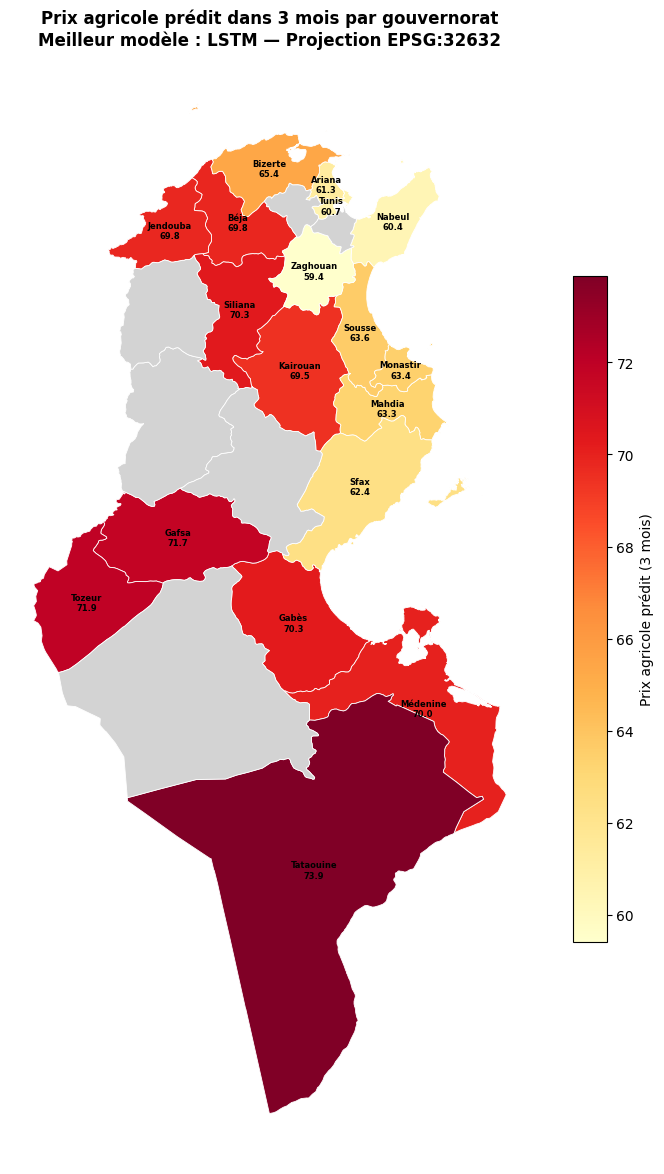

In [ ]:
fig, ax = plt.subplots(figsize=(9, 12))

gdf.plot(
    column='lstm_moyen',
    cmap='YlOrRd',
    linewidth=0.6,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Prix agricole prédit (3 mois)',
        'orientation': 'vertical',
        'shrink': 0.6
    },
    ax=ax,
    missing_kwds={'color': 'lightgrey'}
)

# Nom + valeur par gouvernorat
for _, row in gdf.iterrows():
    if row.geometry is not None and not pd.isna(row.get('lstm_moyen')):
        centroid = row.geometry.centroid
        ax.annotate(
            f"{row['NAME_1']}\n{row['lstm_moyen']:.1f}",
            xy=(centroid.x, centroid.y),
            fontsize=6, ha='center', va='center',
            color='black', fontweight='bold'
        )

ax.set_title(
    'Prix agricole prédit dans 3 mois par gouvernorat\n'
    'Meilleur modèle : LSTM — Projection EPSG:32632',
    fontsize=12, fontweight='bold'
)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('carte_lstm_tunisie.png', dpi=200, bbox_inches='tight')
plt.show()